# Data Processing

## Dataset Loading

First let's download and import dataset.

In [1]:
from pathlib import Path
import gdown

DATA_DIR = Path("../data")
DATA_DIR.mkdir(parents=True, exist_ok=True)
DATA_PATH = DATA_DIR / "data-gaia.csv"
FILE_ID = "1lmcOKUyvl7TyKaF3P_0AS-l0cm6jzo2S"

if not DATA_PATH.exists():
    url = f"https://drive.google.com/uc?id={FILE_ID}"
    gdown.download(url, str(DATA_PATH), quiet=False)
else:
    print("Dataset already present at", DATA_PATH)


Dataset already present at ../data/data-gaia.csv


In [2]:
import pandas as pd

df = pd.read_csv("../data/data-gaia.csv")
df.head(10)

,Unnamed: 0,RA_ICRS,DE_ICRS,Source,Plx,PM,pmRA,pmDE,Gmag,e_Gmag,...,G-RP,pscol,Teff,Dist,Rad,Lum-Flame,Mass-Flame,Age-Flame,z-Flame,SpType-ELS
0,0,47.451110,2.205457,740830319452928,1.1750,8.488,2.263,-8.181,10.966603,0.002786,...,0.090974,NaN,9406.7,918.2012,2.3686,33.161472,2.255,0.404,0.527215,A
1,1,44.375187,2.895901,1402912413121792,1.8937,16.954,7.031,-15.427,10.369156,0.002801,...,0.163792,NaN,9348.7,679.7121,2.4642,25.817343,2.157,0.336,0.638083,A
2,2,42.959304,2.920459,1546703623466880,2.9732,2.528,1.795,1.780,10.038978,0.002774,...,0.304139,NaN,7520.7,339.8108,1.9321,10.527038,1.688,1.033,0.507551,A
3,3,44.031079,3.203683,1614053005633024,2.2337,10.776,-3.151,-10.305,9.810181,0.002786,...,0.338961,1.5956,7052.3,433.9715,2.9735,20.801886,1.923,1.124,0.368294,A
4,4,45.463599,3.138095,1753553543188992,4.0179,10.053,1.828,9.885,8.163041,0.002800,...,0.091842,NaN,9982.8,251.2483,2.2829,45.868046,2.447,0.320,0.509338,A
5,5,43.784164,3.486814,2058736739430272,11.6458,32.355,29.688,-12.863,6.855547,0.002779,...,0.257051,NaN,7192.3,85.7073,2.0194,9.909233,1.647,1.288,0.459583,A
6,6,47.761310,2.904850,2286193912170880,1.9305,8.954,6.145,-6.512,11.135796,0.002781,...,0.301317,NaN,7587.4,523.6980,1.7781,9.050349,1.647,0.888,0.562250,A
7,7,49.046211,3.700545,2445180716897536,1.8239,10.539,-5.489,-8.996,11.412380,0.002806,...,0.251452,NaN,8026.7,582.2903,1.6118,8.243966,1.678,0.203,0.539492,A
8,8,48.237358,4.055506,2713117956668032,1.7571,5.235,-4.549,-2.590,10.735039,0.002767,...,0.295188,NaN,9404.7,570.0735,2.0581,29.892792,2.216,0.375,0.636643,A
9,9,48.732073,4.300161,2917004348752384,5.7774,6.192,3.129,-5.343,8.814120,0.002829,...,0.206487,NaN,7672.9,174.0394,1.5309,7.153093,1.600,0.424,0.432615,A


And remove the innecessary columns.

In [3]:
df = df.drop(columns=['Unnamed: 0', 'Source'])
df.head(10)

,RA_ICRS,DE_ICRS,Plx,PM,pmRA,pmDE,Gmag,e_Gmag,BPmag,e_BPmag,...,G-RP,pscol,Teff,Dist,Rad,Lum-Flame,Mass-Flame,Age-Flame,z-Flame,SpType-ELS
0,47.451110,2.205457,1.1750,8.488,2.263,-8.181,10.966603,0.002786,11.007946,0.002966,...,0.090974,NaN,9406.7,918.2012,2.3686,33.161472,2.255,0.404,0.527215,A
1,44.375187,2.895901,1.8937,16.954,7.031,-15.427,10.369156,0.002801,10.441856,0.003698,...,0.163792,NaN,9348.7,679.7121,2.4642,25.817343,2.157,0.336,0.638083,A
2,42.959304,2.920459,2.9732,2.528,1.795,1.780,10.038978,0.002774,10.212755,0.002847,...,0.304139,NaN,7520.7,339.8108,1.9321,10.527038,1.688,1.033,0.507551,A
3,44.031079,3.203683,2.2337,10.776,-3.151,-10.305,9.810181,0.002786,10.008457,0.002864,...,0.338961,1.5956,7052.3,433.9715,2.9735,20.801886,1.923,1.124,0.368294,A
4,45.463599,3.138095,4.0179,10.053,1.828,9.885,8.163041,0.002800,8.197672,0.003043,...,0.091842,NaN,9982.8,251.2483,2.2829,45.868046,2.447,0.320,0.509338,A
5,43.784164,3.486814,11.6458,32.355,29.688,-12.863,6.855547,0.002779,6.993539,0.003118,...,0.257051,NaN,7192.3,85.7073,2.0194,9.909233,1.647,1.288,0.459583,A
6,47.761310,2.904850,1.9305,8.954,6.145,-6.512,11.135796,0.002781,11.308662,0.002958,...,0.301317,NaN,7587.4,523.6980,1.7781,9.050349,1.647,0.888,0.562250,A
7,49.046211,3.700545,1.8239,10.539,-5.489,-8.996,11.412380,0.002806,11.550269,0.003149,...,0.251452,NaN,8026.7,582.2903,1.6118,8.243966,1.678,0.203,0.539492,A
8,48.237358,4.055506,1.7571,5.235,-4.549,-2.590,10.735039,0.002767,10.874787,0.003163,...,0.295188,NaN,9404.7,570.0735,2.0581,29.892792,2.216,0.375,0.636643,A
9,48.732073,4.300161,5.7774,6.192,3.129,-5.343,8.814120,0.002829,8.915595,0.003307,...,0.206487,NaN,7672.9,174.0394,1.5309,7.153093,1.600,0.424,0.432615,A


## Missing Value Handling

Now, we have to analyze the dataset's null values. When working with astronomical data such as Gaia's, _null_ values aren't usually random erros but stars that are very far away or too faint to measure.

<Axes: >

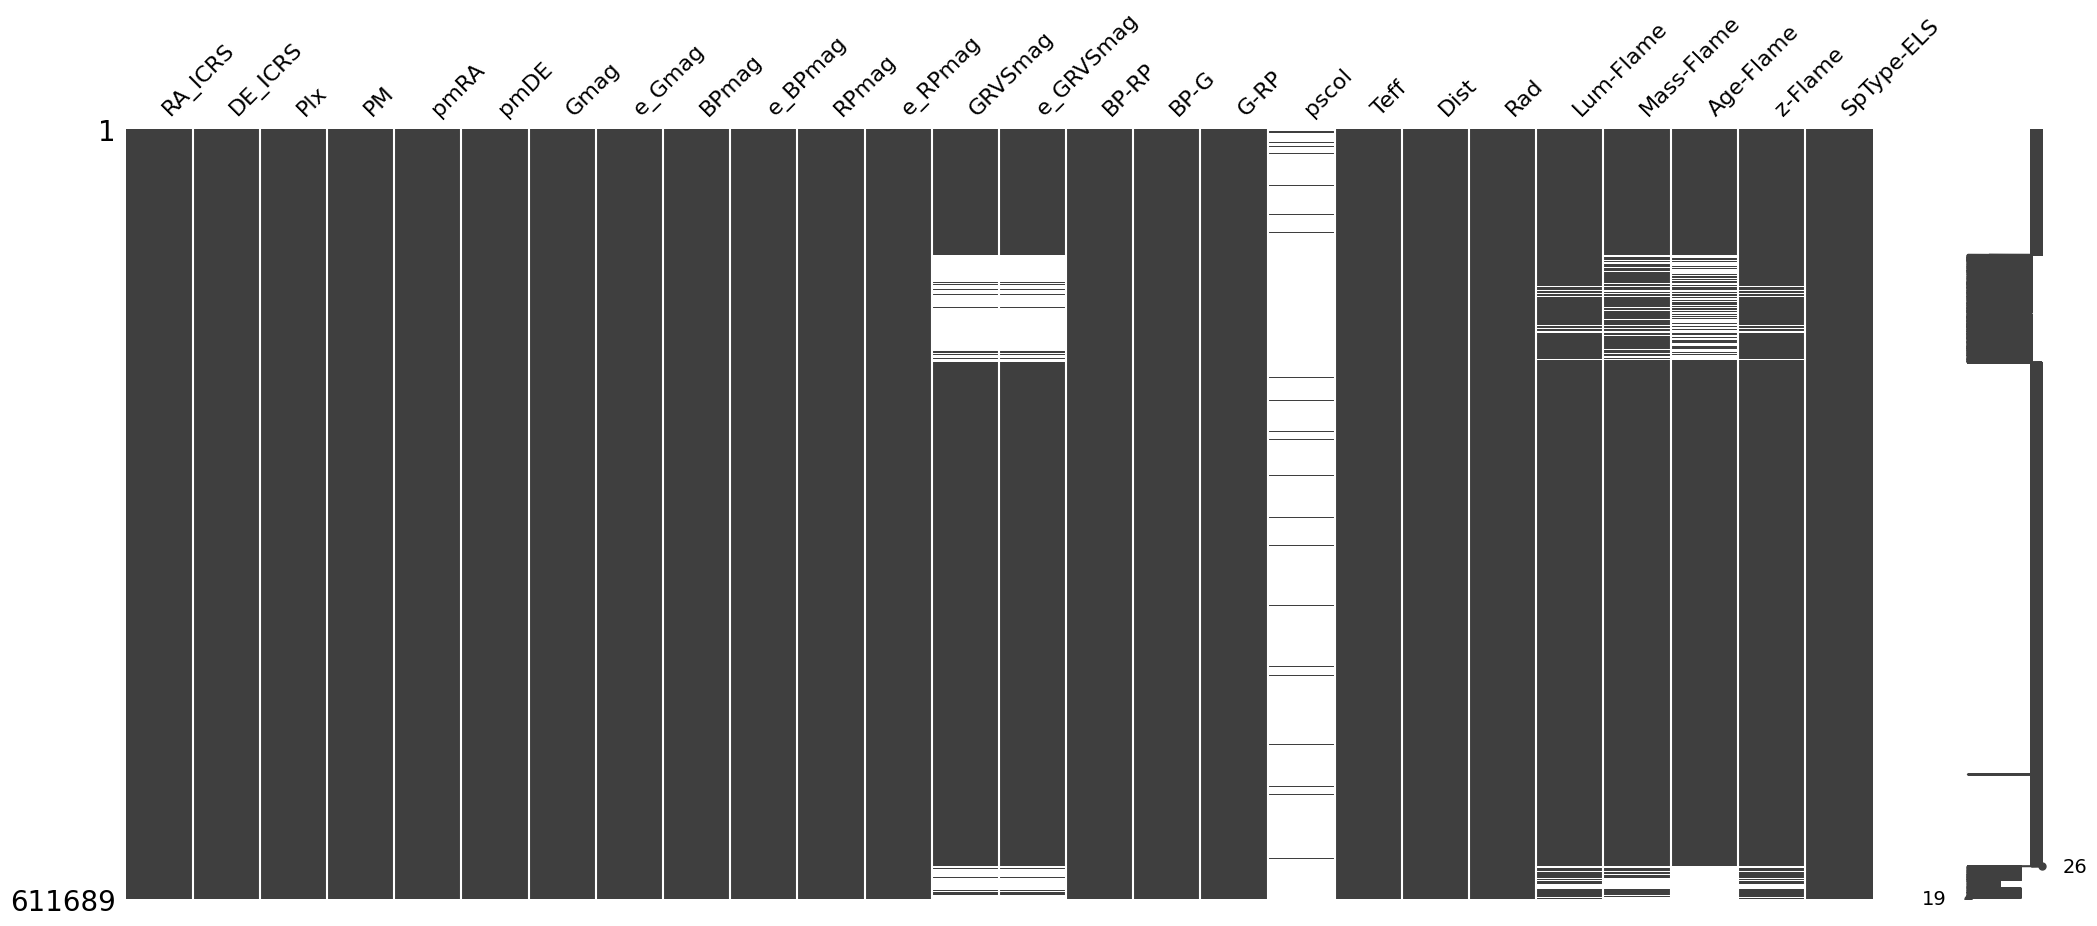

In [4]:
import missingno as msno

msno.matrix(df)

An interesting thing that this graph shows us is the correlation of values, obviously 'e_GRVSmag' cannot be calculated without 'GRVSmag', as it's its error and 'Lum-Flame', 'Mass-Flame', 'Age-Flame' and 'z-Flame' seem to be correlated to.

 Let's check the percentage of missing values for each variable.

In [5]:
(df.isnull().sum() / len(df)) * 100

RA_ICRS        0.000000
DE_ICRS        0.000000
Plx            0.000000
PM             0.000000
pmRA           0.000000
pmDE           0.000000
Gmag           0.000163
e_Gmag         0.000163
BPmag          0.000163
e_BPmag        0.000163
RPmag          0.000000
e_RPmag        0.000000
GRVSmag       16.996873
e_GRVSmag     16.996873
BP-RP          0.000163
BP-G           0.000163
G-RP           0.000163
pscol         97.320861
Teff           0.000000
Dist           0.000000
Rad            0.000000
Lum-Flame      2.310161
Mass-Flame     5.350431
Age-Flame     12.042231
z-Flame        2.310161
SpType-ELS     0.000000
dtype: float64

Seeing the null percentages per column we can reach some conclussions:
* **pscol**: it's missing almost every value, it's not worth it to keep it so we remove it.
* **Gmag**, **BPmag**, **BP-RP**: they are missing just one value, which is in fact curious.
* **GRVSmag**, **Age-Flame**, **Mass-Flame**, **Lum-Flame**: they are missing around 2% and 17%. Removing the rows would mean losing more than 100k stars, some of which could be class **O** or **B**. So we use **IterativeImputer (MICE)** after splitting our dataset to avoid data leakage.

**Why IterativeImputer over SimpleImputer?**
- **SimpleImputer** (median/mean): Fills with a constant value, ignoring relationships between variables. This artificially breaks correlations and is unrealistic for astronomical data.
- **IterativeImputer (MICE)**: Iteratively estimates missing values *using relationships with other variables*. This preserves the physical correlations between stellar properties (Luminosity, Mass, Age, Redshift) and produces realistic imputations. Essential for scientific data.

In [6]:
# remove 'pscol'
df = df.drop(columns=['pscol'])

# remove the missing row
df = df.dropna(subset=['Gmag', 'e_Gmag', 'BPmag', 'e_BPmag', 'BP-RP', 'BP-G', 'G-RP'])

# The imputation is done after train/test split to avoid data leakage

(df.isnull().sum() / len(df)) * 100

RA_ICRS        0.000000
DE_ICRS        0.000000
Plx            0.000000
PM             0.000000
pmRA           0.000000
pmDE           0.000000
Gmag           0.000000
e_Gmag         0.000000
BPmag          0.000000
e_BPmag        0.000000
RPmag          0.000000
e_RPmag        0.000000
GRVSmag       16.996900
e_GRVSmag     16.996900
BP-RP          0.000000
BP-G           0.000000
G-RP           0.000000
Teff           0.000000
Dist           0.000000
Rad            0.000000
Lum-Flame      2.310165
Mass-Flame     5.350440
Age-Flame     12.042250
z-Flame        2.310165
SpType-ELS     0.000000
dtype: float64

## Making the Dataset Imbalanced

As the projects explicitly asks for an imbalanced dataset, let's imbalance it artificially. We will try to closely match the following observed distribution shown in [1](https://www.researchgate.net/publication/1892445_A_Near-Infrared_Stellar_Spectral_Library_II_K-Band_Spectra).

- M: 60,000
- K: 100,000
- G: 85,000
- F: 75,000
- A: 50,000
- B: 55,000
- O: 2,000

In [7]:
print(df['SpType-ELS'].unique())
df['SpType-ELS'] = df['SpType-ELS'].str.strip() # remove leading and trailing spaces
print(df['SpType-ELS'].unique())

<StringArray>
['A      ', 'B      ', 'F      ', 'G      ', 'K      ', 'M      ', 'O      ']
Length: 7, dtype: str
<StringArray>
['A', 'B', 'F', 'G', 'K', 'M', 'O']
Length: 7, dtype: str


In [8]:
rows_per_class = {
    'M': 60000,
    'K': 100000,
    'G': 85000,
    'F': 75000,
    'A': 50000,
    'B': 55000,
    'O': 2000
}

df_filtered = []

# sample the dataframe according to the specified amount of rows per class
for star_type, amount in rows_per_class.items():
    df_class = df[df['SpType-ELS'] == star_type]
    
    # if asked more rows than the class has, we take all the rows of that class
    real_amount = min(amount, len(df_class)) 
    
    df_class_sample = df_class.sample(n=real_amount, random_state=42)
    df_filtered.append(df_class_sample)

# concatenate the filtered dataframes and shuffle the resulting dataframe
df = pd.concat(df_filtered).sample(frac=1, random_state=42).reset_index(drop=True)

# check the distribution of the classes
print(df['SpType-ELS'].value_counts())

SpType-ELS
K    100000
G     85000
F     75000
M     60000
B     55000
A     50000
O      2000
Name: count, dtype: int64


## Correlation Analysis

It's time to analyze the correlations between variables. In our dataset we expect high correlation between some variables, such as 'BPmag' and 'RPmag', as they are matematically correlated.

Let's first encode the objective variable.

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Target'] = le.fit_transform(df['SpType-ELS'])
df = df.drop(columns=['SpType-ELS']) # remove the original column
df.head(10)

,RA_ICRS,DE_ICRS,Plx,PM,pmRA,pmDE,Gmag,e_Gmag,BPmag,e_BPmag,...,BP-G,G-RP,Teff,Dist,Rad,Lum-Flame,Mass-Flame,Age-Flame,z-Flame,Target
0,105.051773,27.770274,2.2224,15.542,4.533,-14.866,10.352516,0.002793,10.464497,0.002889,...,0.111980,0.202487,7842.3,483.7066,2.0010,11.709130,1.747,0.821,0.586310,0
1,38.725427,10.303776,0.2915,14.886,-5.054,-14.002,14.211969,0.002765,14.681272,0.003181,...,0.469302,0.637755,5887.6,3327.2627,5.4090,26.160244,2.023,1.090,0.448535,3
2,274.552529,-26.174652,0.1135,5.109,-2.195,-4.613,14.650004,0.002834,15.797163,0.026198,...,1.147159,1.179017,5061.6,2599.6711,11.5264,78.783490,2.900,0.414,0.105888,5
3,82.442045,36.213829,0.1922,0.994,0.894,0.433,15.311323,0.002788,16.405636,0.003968,...,1.094313,1.034681,5192.1,2979.4353,7.5723,37.434597,2.702,0.502,0.151563,4
4,334.641382,24.448738,4.9204,21.396,16.582,13.522,15.203747,0.002805,16.287430,0.004128,...,1.083683,1.038814,3806.9,202.5859,0.5882,0.065924,0.576,13.134,0.614816,5
5,79.149382,30.697550,0.9153,9.071,6.834,-5.965,13.682287,0.002761,14.143663,0.002883,...,0.461376,0.629046,5604.3,888.6251,1.8580,4.431390,1.254,4.720,0.359333,3
6,39.790454,13.386893,3.5082,41.289,38.857,-13.961,14.217662,0.002776,14.869917,0.003610,...,0.652255,0.771402,4556.5,279.8329,0.6866,0.186710,0.727,6.945,0.654224,4
7,13.054550,65.318942,0.1378,2.278,-2.167,-0.702,16.928846,0.003069,17.497213,0.005618,...,0.568367,0.823244,9742.3,2790.4910,1.3467,15.496695,NaN,NaN,0.744165,1
8,31.159597,22.206979,1.0189,18.542,-2.540,-18.367,14.149289,0.002818,14.521359,0.003834,...,0.372070,0.544946,5791.2,934.9641,1.3444,1.845948,1.007,9.698,0.404040,3
9,48.687798,19.015632,1.1937,2.792,0.181,-2.786,13.396058,0.002794,13.761439,0.003008,...,0.365381,0.538734,5782.7,656.5281,1.3152,2.628577,1.062,8.557,0.401267,3


Now we can see the correlation matrix.

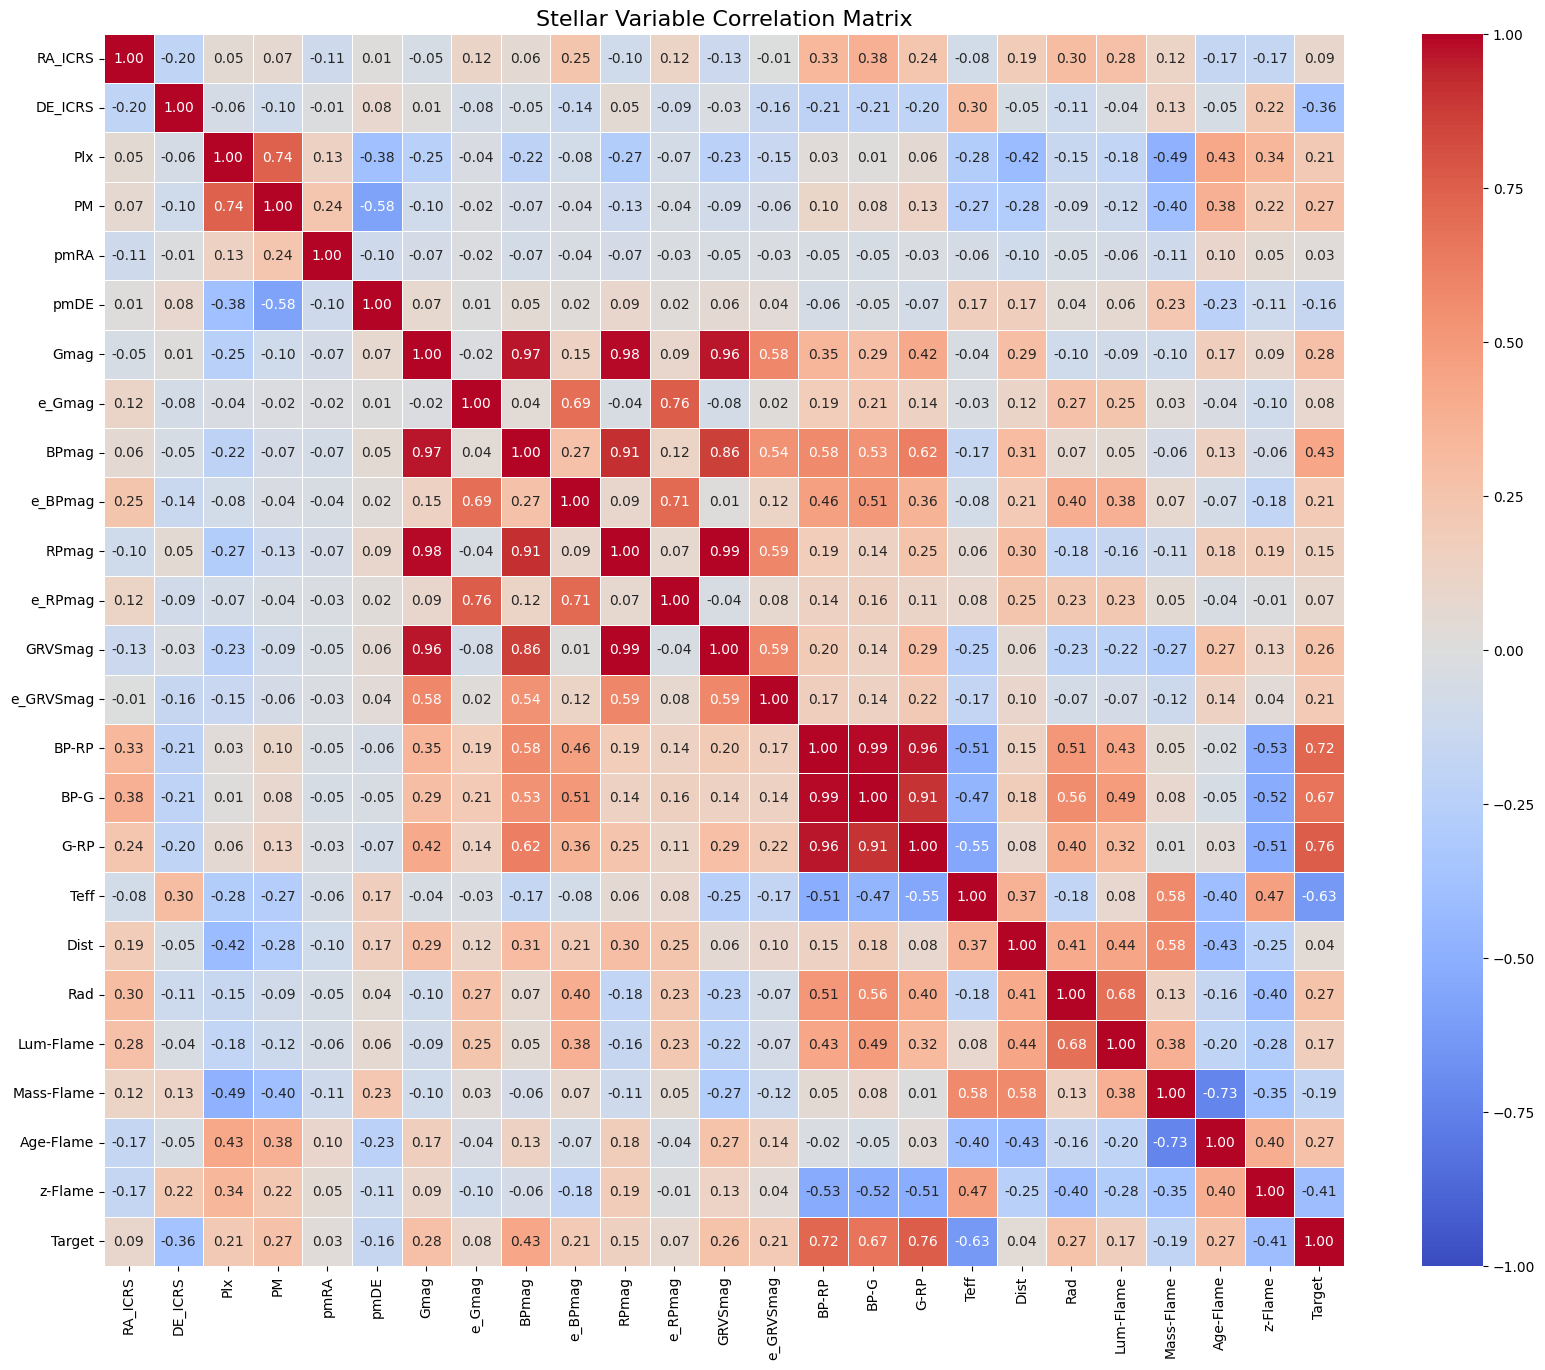

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation_matrix = df.select_dtypes(include=['float64', 'int64', 'int32']).corr()

plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, 
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            vmin=-1, vmax=1,
            linewidths=0.5)

plt.title('Stellar Variable Correlation Matrix', fontsize=16)
plt.show()

Seeing this correlation matrix we can get some conclussions:
- 'Gmag', 'BPmag', 'RPmag' and 'GRVSmag' have the most red blocks on the graph. 'Gmag' and 'RPmag' have 98% of correlation, 'Gmag' and 'BPmag' 95%, 'Gmag' and 'GRVSmag' 93% and 'GRVSmag' and 'RPmag' 96%. Even if it is a lower percentage, 'RPmag' and 'BPmag' have 88% of correlation.
- 'BP-G', 'G-RP' and 'BP-RP' have the most intense red blocks on the graph. 'BP-RP' and 'BP-G' have 99% of correlation, 'G-RP' and 'BP-RP' 96% and 'BP-G' and 'G-RP' 91%.
- We did not understand why some variables that are theoretically mathematically related had such low correlation values. Our theory is that the matrix only sees linear relations.

We will take the following actions:
- Remove 'BPmag', 'RPmag' and 'GRVSmag' as they are photometric clones of 'Gmag'.
- Remove 'BP-G' and 'G-RP' as they are not as used as 'BP-RP'.
- Remove all the error variables as they are just noise.

In [11]:
columns_to_drop = [
    'BPmag', 'RPmag', 'GRVSmag',
    'BP-G', 'G-RP',
    'e_Gmag', 'e_BPmag', 'e_RPmag', 'e_GRVSmag'
]

df = df.drop(columns=columns_to_drop)

print(f"Number of final variables: {df.shape[1]}")

Number of final variables: 16


## Data scalation

To prevent data leakage we have to split our data before escaling it, this way the the model does not get any information from test when training.

First we separate the test data, and then we perform another split to get the validation data.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

X = df.drop(columns=['Target'])
y = df['Target']

# separate TEST
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y # TODO: Not sure if I should stratify here (Is this data leakage?)
)

Now, as mentioned before, we can perform imputation.

We chose IterativeImputer (MICE) because it doesn't fill the gaps with a single number (we used the median with SimpleImputer before). It basically performs machine learning trying to predict the values for missing ones and it is considered very robust.

In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

columns_to_imputate = ['Lum-Flame', 'Mass-Flame', 'Age-Flame', 'z-Flame']
imputer = IterativeImputer(estimator=None, max_iter=10, random_state=42)

# Fit on train and transform train
X_train[columns_to_imputate] = imputer.fit_transform(X_train[columns_to_imputate])

# Apply the same imputation to test (learned from train only)
X_test[columns_to_imputate] = imputer.transform(X_test[columns_to_imputate])

print("Data split and imputed successfully with MICE!")
print(f"Train set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Data split and imputed successfully with MICE!
Train set shape: (341600, 15)
Test set shape: (85400, 15)


# Imbalance Analysis and Mitigation

## Class Distribution

This results are not particularly surpising given that we have purposefully unbalanced the dataset in advance. Anyways, the following distribution shows that we have a long-tail class distribution, which resembles the actual distribution of stars as described in [1](https://www.researchgate.net/publication/1892445_A_Near-Infrared_Stellar_Spectral_Library_II_K-Band_Spectra). We can apreciate a severe imbalance between the O class stars and the rest, while the other classes only present a slight imbalance of at most around 50%.

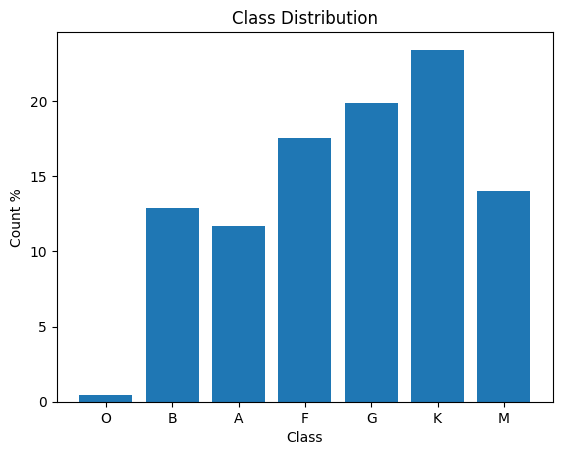

In [12]:

classes = ['O', 'B', 'A', 'F', 'G', 'K', 'M']
encoded_classes = le.transform(classes)

class_percent = df["Target"].value_counts(normalize=True) * 100
class_percent = class_percent.reindex(encoded_classes)

plt.bar(x=classes, height=class_percent.values)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count %")
plt.show()

## Imbalance Mitigation

Lets start comparing the different class imbalance mitigation techniques by getting a baseline on our dataset. Throughout the next experiments we will be using a Linear Support Vector Classifier with a "One vs Rest" strategy as our baseline model although we will later test a plethora of different classic and ensemble methods in the next section. Also note that we will be using a RobustScaler instead of a StandardScaler in all of the experiments since there is great variation among different star espectral classes, and RobustScaler it is more resilient to outliers.

In [ ]:
from sklearn.preprocessing import  RobustScaler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, classification_report
from imblearn.metrics import geometric_mean_score

def run_pipeline(pipe, X_train, X_test, y_train, y_test, exp_name=None):
    
    # Fit and predict through the pipeline
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    # Compute metrics and display results
    acc = accuracy_score(y_test, y_pred)
    precision_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    gmean = geometric_mean_score(y_test, y_pred, average='macro')
    mcc = matthews_corrcoef(y_test, y_pred)
    
    print(f"\n==== Experiment: {exp_name} ====")
    print(f"Accuracy         : {acc:.4f}")
    print(f"Precision (macro): {precision_macro:.4f}")
    print(f"Recall (macro)   : {recall_macro:.4f}")
    print(f"F1-score (macro) : {f1_macro:.4f}")
    print(f"G-Mean (macro)   : {gmean:.4f}")
    print(f"MCC              : {mcc:.4f}")

    print("\nPredicted class distribution:")
    print(pd.Series(y_pred).value_counts().sort_index())


### Baseline

The baseline dataset with no oversampling/undersampling achieves an overall accuracy of 80.33% and a macro F1 of 0.8263. However, the minority class "O" is clearly underpredicted due to the sever class imbalance with only 305 data points being classified as such (There should be around 2000*0.80=1600 "O" class stars in the training dataset).

In [15]:
from sklearn.svm import LinearSVC

pipe = ImbPipeline([
    ('scaler', RobustScaler()),
    ('clf', LinearSVC(random_state=42, multi_class="ovr"))
])

run_pipeline(pipe, X_train, X_test, y_train, y_test, exp_name="Baseline (No resampling)")


==== Experiment: Baseline (No resampling) ====
Accuracy         : 0.8033
Precision (macro): 0.8476
Recall (macro)   : 0.8105
F1-score (macro) : 0.8263
G-Mean (macro)   : 0.8845
MCC              : 0.7618

Predicted class distribution:
0     9723
1    11058
2    16655
3    17246
4    19012
5    11401
6      305
Name: count, dtype: int64


### Class Weighting

Using class weighting does not really improve the metrics overall, although it does increase the number of predicted "O" class stars from 305 to 433.

In [16]:

pipe = ImbPipeline([
    ('scaler', RobustScaler()),
    ('clf', LinearSVC(random_state=42, multi_class="ovr", class_weight="balanced"))
])

run_pipeline(pipe, X_train, X_test, y_train, y_test, exp_name="Class Weighting")


==== Experiment: Class Weighting ====
Accuracy         : 0.8013
Precision (macro): 0.8191
Recall (macro)   : 0.8300
F1-score (macro) : 0.8235
G-Mean           : 0.8950
MCC              : 0.7601

Predicted class distribution:
0    10401
1    10949
2    17280
3    16283
4    18303
5    11751
6      433
Name: count, dtype: int64


### Random Oversampling

Random oversampling does slightly increase recall and G-Mean, but precission drops slightly. This drop in precission might come from the model overfitting to the minority class due to the replicated minority class samples caused by oversampling. Again, the number of samples predicted as "O" seems to increase.

In [18]:
from imblearn.over_sampling import RandomOverSampler

pipe = ImbPipeline([
    ('scaler', RobustScaler()),
    ('ros', RandomOverSampler(random_state=42)),
    ('clf', LinearSVC(random_state=42, multi_class="ovr"))
])

run_pipeline(pipe, X_train, X_test, y_train, y_test, exp_name="Random Over Sampling")


==== Experiment: Random Over Sampling ====
Accuracy         : 0.7898
Precision (macro): 0.7797
Recall (macro)   : 0.8354
F1-score (macro) : 0.7989
G-Mean (macro)   : 0.8970
MCC              : 0.7469

Predicted class distribution:
0    10604
1    10707
2    17861
3    16253
4    17459
5    11844
6      672
Name: count, dtype: int64


### SMOTE

SMOTE shows similar results to those obtained with standard random oversampling, with a slightly higher F1-score of 0.8007.

In [ ]:
from imblearn.over_sampling import SMOTE

pipe = ImbPipeline([
    ('scaler', RobustScaler()),
    ('smote', SMOTE(random_state=42)),
    ('clf', LinearSVC(random_state=42, multi_class="ovr"))
])

run_pipeline(pipe, X_train, X_test, y_train, y_test, exp_name="SMOTE")



==== Experiment: SMOTE ====
Accuracy         : 0.7897
Precision (macro): 0.7817
Recall (macro)   : 0.8354
F1-score (macro) : 0.8007
G-Mean           : 0.8970
MCC              : 0.7467

Predicted class distribution:
0    10701
1    10700
2    17808
3    16180
4    17515
5    11845
6      651
Name: count, dtype: int64


### ADASYN

ADASYN seems to underperform SMOTE in most metrics. It is also important to note thhat ADASYN only seems to work with the "minority" sampling strategy. This likely happens because ADASYN focuses on generating "hard to learn" samples in the boundary between two classes, and it might fail when genrating classes for non minority classes since it can not identify a "hard to learn" region.

In [ ]:
from imblearn.over_sampling import ADASYN

pipe = ImbPipeline([
    ('scaler', RobustScaler()),
    ('adasyn', ADASYN(random_state=42, sampling_strategy="minority")),
    ('clf', LinearSVC(random_state=42, multi_class="ovr"))
])

run_pipeline(pipe, X_train, X_test, y_train, y_test, exp_name="ADASYN")



==== Experiment: ADASYN ====
Accuracy         : 0.7939
Precision (macro): 0.7590
Recall (macro)   : 0.8345
F1-score (macro) : 0.7762
G-Mean           : 0.8969
MCC              : 0.7507

Predicted class distribution:
0     9815
1    10299
2    16615
3    17235
4    18987
5    11391
6     1058
Name: count, dtype: int64


### Random Undersampling

Recall improves slightly, but accuracy drops to 0.7899. This is also considerably faster since a lot of samples are removed from the dataset to balance the classes.

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

pipe = ImbPipeline([
    ('scaler', RobustScaler()),
    ('rus', RandomUnderSampler(random_state=42)),
    ('clf', LinearSVC(random_state=42, multi_class="ovr"))
])

run_pipeline(pipe, X_train, X_test, y_train, y_test, exp_name="Random Under Sampling")


==== Experiment: Random Under Sampling ====
Accuracy         : 0.7899
Precision (macro): 0.7758
Recall (macro)   : 0.8347
F1-score (macro) : 0.7959
G-Mean           : 0.8967
MCC              : 0.7467

Predicted class distribution:
0    10597
1    10765
2    17536
3    16272
4    17790
5    11738
6      702
Name: count, dtype: int64


### Nearmiss

Nearmiss seems to underperform all the previous methods in all metrics. The algorithm aggressively undersamples the mayority class by keeping only close samples, but there seems to be quite a lot of distance between the mayority and minority samples in our dataset. The v2 version of Nearmiss works even worst than the first one, and the v3 version  didn't even work since it was not able to achieve class balance whith such imbalance between the mayority and minority classes.

In [ ]:
from imblearn.under_sampling import NearMiss

for version in [1, 2]:
    pipe = ImbPipeline([
        ('scaler', RobustScaler()),
        ('nm', NearMiss(version=version)),
        ('clf', LinearSVC(random_state=42, multi_class="ovr"))
    ])

    run_pipeline(pipe, X_train, X_test, y_train, y_test, exp_name=f"NearMiss v{version}")


==== Experiment: NearMiss v1 ====
Accuracy         : 0.5619
Precision (macro): 0.6928
Recall (macro)   : 0.6047
F1-score (macro) : 0.5828
G-Mean           : 0.7471
MCC              : 0.5080

Predicted class distribution:
0    12188
1     5334
2     4060
3    43945
4    12843
5     6412
6      618
Name: count, dtype: int64

==== Experiment: NearMiss v2 ====
Accuracy         : 0.3798
Precision (macro): 0.5453
Recall (macro)   : 0.4913
F1-score (macro) : 0.3891
G-Mean           : 0.6624
MCC              : 0.3131

Predicted class distribution:
0    11348
1     3488
2    53722
3     7502
4     2497
5     5536
6     1307
Name: count, dtype: int64


### SMOTE + ENN

Applying ENN after SMOTE does not seem to improve the results in this dataset.

In [27]:
from imblearn.combine import SMOTEENN

pipe = ImbPipeline([
    ('scaler', RobustScaler()),
    ('smoteenn', SMOTEENN(random_state=42)),
    ('clf', LinearSVC(random_state=42, multi_class="ovr"))
])

run_pipeline(pipe, X_train, X_test, y_train, y_test, exp_name="SMOTE + ENN")


==== Experiment: SMOTE + ENN ====
Accuracy         : 0.7841
Precision (macro): 0.7759
Recall (macro)   : 0.8327
F1-score (macro) : 0.7943
G-Mean           : 0.8952
MCC              : 0.7416

Predicted class distribution:
0    10713
1    10734
2    19622
3    14300
4    17119
5    12251
6      661
Name: count, dtype: int64


### SMOTE + Tomek's Links

Aplying Tomek's Links after SMOTE also does not seem to improve SMOTE's results in this dataset.

In [30]:
from imblearn.combine import SMOTETomek

pipe = ImbPipeline([
    ('scaler', RobustScaler()),
    ('smotetomek', SMOTETomek(random_state=42)),
    ('clf', LinearSVC(random_state=42, multi_class="ovr"))
])

run_pipeline(pipe, X_train, X_test, y_train, y_test, exp_name="SMOTE + Tomek Links")


==== Experiment: SMOTE + Tomek Links ====
Accuracy         : 0.7887
Precision (macro): 0.7809
Recall (macro)   : 0.8349
F1-score (macro) : 0.7999
G-Mean           : 0.8967
MCC              : 0.7457

Predicted class distribution:
0    10699
1    10710
2    18060
3    15958
4    17427
5    11895
6      651
Name: count, dtype: int64


### Comparision

| Imbalance Method           | Accuracy | Precision (macro) | Recall (macro) | F1-score (macro) | G-Mean  | MCC    |
|----------------------------|----------|-----------------|----------------|-----------------|---------|--------|
| Baseline (No resampling)   | 0.8033   | 0.8476          | 0.8105         | 0.8263          | 0.8845  | 0.7618 |
| Class Weighting            | 0.8013   | 0.8191          | 0.8300         | 0.8235          | 0.8950  | 0.7601 |
| Random Over Sampling       | 0.7898   | 0.7797          | 0.8354         | 0.7989          | 0.8970  | 0.7469 |
| SMOTE                      | 0.7897   | 0.7817          | 0.8354         | 0.8007          | 0.8970  | 0.7467 |
| ADASYN                     | 0.7939   | 0.7590          | 0.8345         | 0.7762          | 0.8969  | 0.7507 |
| Random Under Sampling      | 0.7899   | 0.7758          | 0.8347         | 0.7959          | 0.8967  | 0.7467 |
| NearMiss v1                | 0.5619   | 0.6928          | 0.6047         | 0.5828          | 0.7471  | 0.5080 |
| NearMiss v2                | 0.3798   | 0.5453          | 0.4913         | 0.3891          | 0.6624  | 0.3131 |
| SMOTE + ENN                | 0.7841   | 0.7759          | 0.8327         | 0.7943          | 0.8952  | 0.7416 |
| SMOTE + Tomek Links        | 0.7887   | 0.7809          | 0.8349         | 0.7999          | 0.8967  | 0.7457 |

Overall, methods like random oversampling, SMOTE, ADASYN, random undersampling and combined methods seem to slightly improve recall at the cost of some precission. The macro F1-scores are still slightly higher with no imbalance handling, and the maximum G-Mean score of 0.987 is achieved with simple oversampling techniques while MCC still favours the baseline approach. The relatively mediocre results from most resampling methods are likely because the different star classes, although severely imbalanced, are still quite separable in feature space, so the classifier can already distinguish them reasonably well even without extensive resampling. We will test some of this strategies in the next section with more advance models to determine whether they can make a difference.

# Model Comparison and Hyperparameter Tuning

### Dummy Classifier (Baseline)

We will use a DummyClassifier that just predicts all the samples in the dataset to belong to the majority class as a baseline to compare the rest of the models. The metrics obtained by this model are unsirprisingly poor.

In [31]:
from sklearn.dummy import DummyClassifier

pipe = ImbPipeline([
    ("scaler", RobustScaler()),
    ("clf", DummyClassifier(strategy="most_frequent"))
])

run_pipeline(pipe, X_train, X_test, y_train, y_test, "Dummy")


==== Experiment: Dummy ====
Accuracy         : 0.2342
Precision (macro): 0.0335
Recall (macro)   : 0.1429
F1-score (macro) : 0.0542
G-Mean (macro)   : 0.3499
MCC              : 0.0000

Predicted class distribution:
4    85400
Name: count, dtype: int64


### Decision Tree

We trained a simple DecisionTree and found the optimum max_depth and min_samples_leaf parameters with a 3 fold RandomizedSearchCV. This model, although relatively simple, actually achives decent performance with a macro F-score of 0.9178 and an MCC of 0.8798.

In [32]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_dt = {"clf__max_depth": [5, 10, 15, None], "clf__min_samples_leaf": [1, 2, 5]}
pipe_dt = ImbPipeline([
    ("scaler", RobustScaler()),
    ("clf", DecisionTreeClassifier(random_state=42))]
)

search_dt = RandomizedSearchCV(pipe_dt, param_dt, cv=3, scoring="f1_macro", n_jobs=-1)
search_dt.fit(X_train, y_train)

run_pipeline(search_dt.best_estimator_, X_train, X_test, y_train, y_test, "Decision Tree")


==== Experiment: Decision Tree ====
Accuracy         : 0.9009
Precision (macro): 0.9199
Recall (macro)   : 0.9159
F1-score (macro) : 0.9178
G-Mean (macro)   : 0.9486
MCC              : 0.8798

Predicted class distribution:
0     9965
1    11018
2    15546
3    16450
4    20128
5    11905
6      388
Name: count, dtype: int64


### Logistic Regression

We trained a LogisticRegression model (which defaults to multinomial logistic regression in multiclass datasets) and searched for the regularization parameter "C" with a simple cross validation grid search. This simple model achieved acceptable performance although it still falls behind the simple decision tree tested before.

In [ ]:
from sklearn.linear_model import LogisticRegression

param_lr = {"clf__C": [0.01, 0.1, 1, 10], "clf__solver": ["lbfgs"]}
pipe_lr = ImbPipeline([
    ("scaler", RobustScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

search_lr = GridSearchCV(pipe_lr, param_lr, cv=3, scoring="f1_macro", n_jobs=-1)
search_lr.fit(X_train, y_train)

run_pipeline(search_lr.best_estimator_, X_train, X_test, y_train, y_test, "Logistic Regression")



==== Experiment: LogisticRegression ====
Accuracy         : 0.8661
Precision (macro): 0.8904
Recall (macro)   : 0.8827
F1-score (macro) : 0.8864
G-Mean           : 0.9283
MCC              : 0.8376

Predicted class distribution:
0    10025
1    10987
2    14594
3    17706
4    19994
5    11711
6      383
Name: count, dtype: int64


### Random Forest

To start with ensemble methods we tested a RandomForest classifier. In this case we performed a deeper hyperparameter search which includes the number of estimators, the maximum depth of each estimator, the maximum number of features (As a function of the total number of features), the min sample split and the min samples per leaf. Since there are a log of combinations out of all this parameters, we used a RandomizedSearchCV to avoid exploring all the combinations, which would take too much time. The model performed very well with an F1 of 0.9278 and an MCC of 0.8926, which is a significant improvement from the single decision tree tested before.

In [33]:
from sklearn.ensemble import RandomForestClassifier

param_rf = {
    "clf__n_estimators": [100, 200, 300], "clf__max_depth": [10, 20, None],
    "clf__max_features": ["sqrt", "log2"], "clf__min_samples_split": [2,5], "clf__min_samples_leaf": [1,2]
}
pipe_rf = ImbPipeline([
    ("scaler", RobustScaler()),
    ("clf", RandomForestClassifier(random_state=42))
])

search_rf = RandomizedSearchCV(pipe_rf, param_rf, cv=3, scoring="f1_macro", n_jobs=-1)
search_rf.fit(X_train, y_train)

run_pipeline(search_rf.best_estimator_, X_train, X_test, y_train, y_test, "Random Forest")



==== Experiment: Random Forest ====
Accuracy         : 0.9110
Precision (macro): 0.9306
Recall (macro)   : 0.9231
F1-score (macro) : 0.9267
G-Mean (macro)   : 0.9532
MCC              : 0.8920

Predicted class distribution:
0     9974
1    11034
2    15225
3    16779
4    20050
5    11960
6      378
Name: count, dtype: int64


### Ada Boost

Then we trained an AdaBoostClassifier, seraching for the optimum number of estimators and learning rate. This parameters controll the number of weak learners and the contributions of each of them. Performance was lower than other ensemble methods, and it took more train to train comparing it to other ensemble methods due to the fact that the training of each learner can not be parallelized.

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

param_ab = { "clf__n_estimators": [50,100,200], "clf__learning_rate": [0.1,0.5,1.0] }
pipe_ab = ImbPipeline([
    ("scaler", RobustScaler()),
    ("clf", AdaBoostClassifier(random_state=42))
])

search_ab = GridSearchCV(pipe_ab, param_ab, cv=3, scoring="f1_macro", n_jobs=-1)
search_ab.fit(X_train, y_train)

run_pipeline(search_ab.best_estimator_, X_train, X_test, y_train, y_test, "AdaBoost")

/home/david/code/class_projects/gaia-stellar-classification/venv/lib/python3.11/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



==== Experiment: AdaBoost ====
Accuracy         : 0.8496
Precision (macro): 0.7466
Recall (macro)   : 0.7438
F1-score (macro) : 0.7438
G-Mean (macro)   : 0.8509
MCC              : 0.8182

Predicted class distribution:
0     9761
1    11348
2    17680
3    15577
4    20371
5    10663
Name: count, dtype: int64


### Histogram Gradient Boosting

We trained an HGB model searching for the maximum number of iterations, maximum depth and learning rate with a cross validated grid search. The model achieved excelent performance with an F1 score of 0.9302, slightly above that obtained by random forest, and an MCC of 0.98578. This model was also significantly faster to train due to its optimized histogram binning method.

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

param_hgb = {"clf__max_iter":[100,200], "clf__max_depth":[3,5], "clf__learning_rate":[0.05,0.1]}
pipe_hgb = ImbPipeline([
    ("scaler", RobustScaler()),
    ("clf", HistGradientBoostingClassifier(random_state=42))
])

search_hgb = GridSearchCV(pipe_hgb, param_hgb, cv=3, scoring="f1_macro", n_jobs=-1)
search_hgb.fit(X_train, y_train)

run_pipeline(search_hgb.best_estimator_, X_train, X_test, y_train, y_test, "HistGradientBoosting")


/home/david/code/class_projects/gaia-stellar-classification/venv/lib/python3.11/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



==== Experiment: HistGradientBoosting ====
Accuracy         : 0.9140
Precision (macro): 0.9338
Recall (macro)   : 0.9268
F1-score (macro) : 0.9302
G-Mean (macro)   : 0.9553
MCC              : 0.8957

Predicted class distribution:
0     9954
1    11026
2    15261
3    16672
4    20160
5    11947
6      380
Name: count, dtype: int64


### XGBoost

We initially tuned an XGB model with a simple cross validated grid search, searching for the number of estimators, maximum depth and learning rate. This approach achieved very strong performance with an F1 of 0.9306 and an MCC of 0.8959, surpasing all the previous models.

In [ ]:
from xgboost import XGBClassifier

param_xgb = {"clf__n_estimators":[100,200], "clf__max_depth":[3,5], "clf__learning_rate":[0.05,0.1]}
pipe_xgb = ImbPipeline([
    ("scaler", RobustScaler()),
    ("clf", XGBClassifier(random_state=42, eval_metric="mlogloss", tree_method="hist"))
])

search_xgb = GridSearchCV(pipe_xgb, param_xgb, cv=3, scoring="f1_macro", n_jobs=-1)
search_xgb.fit(X_train, y_train)

run_pipeline(search_xgb.best_estimator_, X_train, X_test, y_train, y_test, "XGBoost")

/home/david/code/class_projects/gaia-stellar-classification/venv/lib/python3.11/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



==== Experiment: XGBoost ====
Accuracy         : 0.9142
Precision (macro): 0.9339
Recall (macro)   : 0.9275
F1-score (macro) : 0.9306
G-Mean           : 0.9557
MCC              : 0.8959

Predicted class distribution:
0     9957
1    11024
2    15277
3    16635
4    20178
5    11947
6      382
Name: count, dtype: int64


### XGBoost (Optuna)

In this second approach we used Optuna to search through a much larger hyperparameter space, including regularization, subsampling and tree specific parameters. We also included SMOTETomek combination sampling, although it does not seem to make much of a difference in this dataset. The tuning lasted almost 2 hours and resulted in a model with an F1 score of 0.9282, slightly bellow the previously trained XGB model and an MCC score of 0.8977, slightly above the one obtained before. The MCC score is able to capture information from all the elements of the confusion matrix, so it is considered to be more informative in some situations.

In [20]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer
from xgboost import XGBClassifier
import numpy as np
import optuna

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
f1_macro_scorer = make_scorer(f1_score, average="macro")

def objective_xgb(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
    }

    model = XGBClassifier(
        objective="multi:softprob",
        num_class=len(np.unique(y_train)),
        eval_metric="mlogloss",
        tree_method="hist",
        device="cpu",
        random_state=42,
        **params
    )

    pipe = ImbPipeline([
        ("scaler", RobustScaler()),
        ("resample", SMOTETomek(random_state=42)),
        ("clf", model)
    ])

    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=f1_macro_scorer,
        n_jobs=-1
    )

    return scores.mean()

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(),
    pruner=optuna.pruners.MedianPruner()
)

study.optimize(objective_xgb, n_trials=50)

print("Best F1-score:", study.best_value)
print("Best params:", study.best_params)

[I 2026-03-20 10:03:18,989] A new study created in memory with name: no-name-2e1e54f7-fc84-43ee-9adb-ecc48e17abb6
[I 2026-03-20 10:05:29,118] Trial 0 finished with value: 0.918215097693223 and parameters: {'n_estimators': 484, 'max_depth': 7, 'learning_rate': 0.013118894304104928, 'subsample': 0.7472306924260564, 'colsample_bytree': 0.8271625872128092, 'gamma': 1.5878785649083615, 'min_child_weight': 4, 'reg_alpha': 0.008914254934746079, 'reg_lambda': 0.003570492021697202}. Best is trial 0 with value: 0.918215097693223.
[I 2026-03-20 10:08:31,528] Trial 1 finished with value: 0.9265836625523493 and parameters: {'n_estimators': 792, 'max_depth': 6, 'learning_rate': 0.046249181365445834, 'subsample': 0.7407007224633211, 'colsample_bytree': 0.6544142491817577, 'gamma': 0.3952181155826284, 'min_child_weight': 10, 'reg_alpha': 0.018227972828692655, 'reg_lambda': 8.420551982902829}. Best is trial 1 with value: 0.9265836625523493.
[I 2026-03-20 10:09:57,075] Trial 2 finished with value: 0.908

Best F1-score: 0.9280131974021266
Best params: {'n_estimators': 490, 'max_depth': 9, 'learning_rate': 0.1277456755051364, 'subsample': 0.987596256202549, 'colsample_bytree': 0.9439595457336795, 'gamma': 0.07951447881408347, 'min_child_weight': 2, 'reg_alpha': 0.31736048563076924, 'reg_lambda': 0.9271743348734703}


In [21]:
best_xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=len(np.unique(y_train)),
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42,
    **study.best_params
)

final_pipe = ImbPipeline([
    ("scaler", RobustScaler()),
    ("resample", SMOTETomek(random_state=42)),
    ("clf", best_xgb)
])

run_pipeline(final_pipe, X_train, X_test, y_train, y_test, exp_name="XGBoost (Optuna)")


==== Experiment: XGBoost (Optuna) ====
Accuracy         : 0.9156
Precision (macro): 0.9259
Recall (macro)   : 0.9307
F1-score (macro) : 0.9282
G-Mean (macro)   : 0.9575
MCC              : 0.8977

Predicted class distribution:
0     9992
1    10983
2    15612
3    16477
4    19950
5    11972
6      414
Name: count, dtype: int64


### Voting Classifier

As a last set of experimets we tryed combining our best performing models into bigger ensemble models via VotingClassifier and StackedClassifier. Starting with the VotingClassifier, we initialized the 3 models (RandomForest, HGB and XGB) from the previously obtained parameters and trained again. This time we also included SMOTETomek as a resampling etep. The soft-voting model combining RandomForest, XGBoost and HGB achieved performance similar to the best individual model, which indicates that the models are allready strong and somewhat correlated amonst them. It is also important to note that we did not perform any furder hyperparameter tuning with this model and we just kept the hyperparameters found for each of the individual models trained before.

In [29]:
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(
    estimators=[
        ("rf", search_rf.best_estimator_.named_steps["clf"]),
        ("hgb", search_hgb.best_estimator_.named_steps["clf"]),
        ("xgb", best_xgb)
    ],
    voting="soft",
    n_jobs=-1
)

pipe_voting = ImbPipeline([
    ("scaler", RobustScaler()),
    ("resample", SMOTETomek(random_state=42)),
    ("clf", voting_clf)
])

run_pipeline(pipe_voting, X_train, X_test, y_train, y_test, "Voting Ensemble")


==== Experiment: Voting Ensemble ====
Accuracy         : 0.9156
Precision (macro): 0.9237
Recall (macro)   : 0.9307
F1-score (macro) : 0.9271
G-Mean (macro)   : 0.9575
MCC              : 0.8977

Predicted class distribution:
0     9990
1    10983
2    15601
3    16553
4    19882
5    11970
6      421
Name: count, dtype: int64


### Stacking Classifier

Finally we tried stacking the tree cllassifiers with a RandomForestClassifier as the blender model. We also did not perform further hyperparameter tuning in this stacked model. The performance is again comparable but does not significantly outperform individual models. This suggests that the individual learners already capture most of the information in the dataset and are correlated between them. This indicates that model performance is likely bounded more by the dataset than by the model complexity.

In [30]:
from sklearn.ensemble import StackingClassifier

stacking_clf = StackingClassifier(
    estimators=[
        ("rf", search_rf.best_estimator_.named_steps["clf"]),
        ("hgb", search_hgb.best_estimator_.named_steps["clf"]),
        ("xgb", best_xgb)
    ],
    final_estimator=RandomForestClassifier(n_estimators=200, random_state=42),
    cv=3,
    n_jobs=-1,
    passthrough=False
)

pipe_stacking = ImbPipeline([
    ("scaler", RobustScaler()),
    ("resample", SMOTETomek(random_state=42)),
    ("clf", stacking_clf)
])

run_pipeline(pipe_stacking, X_train, X_test, y_train, y_test, "Stacking Ensemble")


==== Experiment: Stacking Ensemble ====
Accuracy         : 0.9142
Precision (macro): 0.9287
Recall (macro)   : 0.9261
F1-score (macro) : 0.9273
G-Mean (macro)   : 0.9550
MCC              : 0.8960

Predicted class distribution:
0     9997
1    11004
2    15436
3    16544
4    20054
5    11974
6      391
Name: count, dtype: int64


# Results Discussion

To see how well our models learned to classify the different types of stars, we evaluated them using metrics like Accuracy, Macro Precision, Macro Recall, Macro F1-Score, Geometric Mean (G-Mean), and the Matthews Correlation Coefficient (MCC). 

Since our dataset is imbalanced , looking only at Accuracy might not show the real performance, metrics like Macro F1-Score, MCC, and G-Mean are much better because they tell us if the model is actually good at predicting all types of stars, also G-Mean specifically helps us see if the models performance is balanced across the majority and minority classes, here are the exact results for all the models we tried, ordered from worst to best:

| Model | Accuracy | Precision (Macro) | Recall (Macro) | F1-Score (Macro) | G-Mean (Macro) | MCC |
|-------|----------|-------------------|----------------|------------------|--------|-----|
| **Baseline** | 0.2342 | 0.0335 | 0.1429 | 0.0542 | 0.3499 | 0.0000 |
| **AdaBoost** | 0.8496 | 0.7466 | 0.7438 | 0.7438 | 0.8509 | 0.8182 |
| **Logistic Regression** | 0.8661 | 0.8904 | 0.8827 | 0.8864 | 0.9283 | 0.8376 |
| **Decision Tree** | 0.9009 | 0.9199 | 0.9159 | 0.9178 | 0.9486 | 0.8798 |
| **Random Forest** | 0.9110 | 0.9306 | 0.9231 | 0.9267 | 0.9532 | 0.8920 |
| **Stacking Ensemble** | 0.9142 | 0.9287 | 0.9261 | 0.9273 | 0.9550 | 0.8960 |
| **HistGradientBoosting** | 0.9140 | 0.9338 | 0.9268 | 0.9302 | 0.9553 | 0.8957 |
| **XGBoost (Default)** | 0.9142 | 0.9339 | 0.9275 | 0.9306 | 0.9557 | 0.8959 |
| **Voting Ensemble** | 0.9156 | 0.9237 | 0.9307 | 0.9271 | 0.9575 | 0.8977 |
| **XGBoost (Optuna Tuned)** | 0.9156 | 0.9259 | 0.9307 | 0.9282 | 0.9575 | 0.8977 |

Looking at the table we can notice a few very interesting things from our experiments, for example the best performing models were all gradient boosting algorithms like XGBoost and HistGradientBoosting, they both scored around 0.93 on the F1-Score and over 0.955 for G-Mean, this metrics confirms they are doing very well identifying the rare star classes just as well as the common ones, very important considering the imbalanced dataset. Also we spent a lot on tuning XGBoost using Optuna to find the perfect parameters, at least it achieved the highest G-Mean (0.9575) against the Voting Ensemble, meaning it was the best at balancing majority and minority classes, but its overall F1-score compared to the standard XGBoost is not much diferent, but in fact tunning worked.

# Lessons Learned

At the end we have some experience it task like this due to previous works, but in fact we learned some new aspecs, for example we noticed imbalance makes models lazy, an initial assumtion that in the end was just like that, as we created an artificial long-tail imbalance to match the real universe, we saw that basic models get lazy, for example our baseline Dummy Classifier simply guessed the most common star class every time. Also we experimented with many balancing techniques, we learned that aggressively cutting data actually hurt our performance by throwing away valuable information, then, adding synthetic data (creating fake but realistic stars to grow the rare classes) helped the models learn the minority classes much better without just memorizing duplicates. Finaly, we have to consider we thought that very complex imbalance techniques would magically solve everything, but they performed almost identically to basic implementatios on this dataset.